# Drawing of SBD-based Power Detector

**Copyright 2026 Simon Dorrer**

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at
http://www.apache.org/licenses/LICENSE-2.0

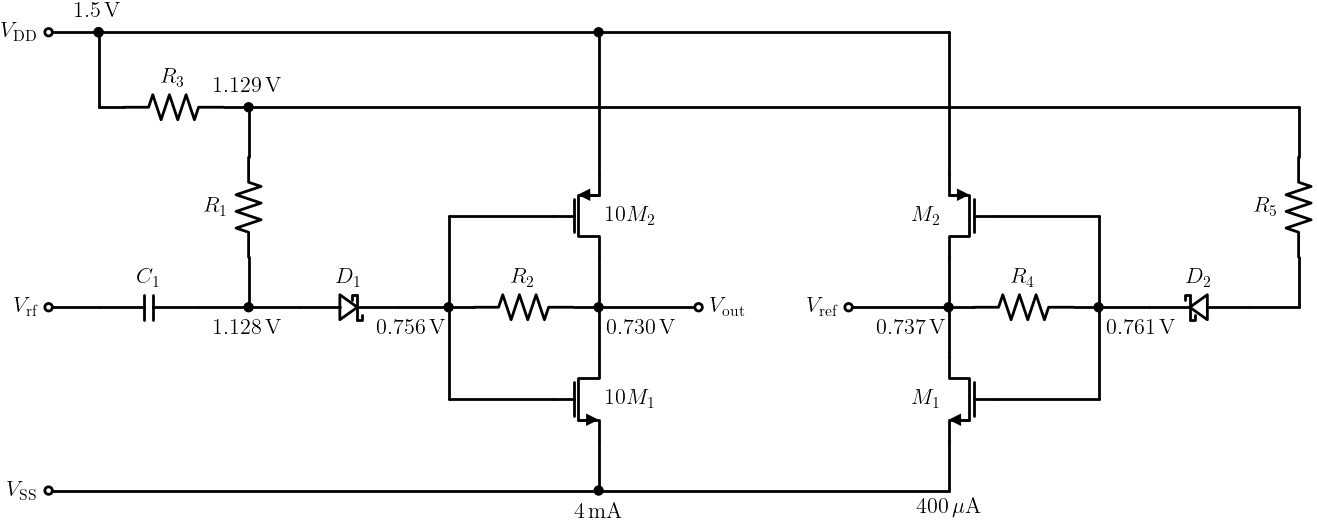

In [10]:
# Drawing of SBD-based Power Detector
import matplotlib
matplotlib.rcParams.update({
    "text.usetex": True,
    "font.family": "lmodern"
})
import schemdraw as sd
import schemdraw.elements as elm
import schemdraw.logic as logic
sd.svgconfig.svg2 = False

with sd.Drawing() as d:
    d.config(unit=2, fontsize=16)

    # Vrf Input, C1, D1
    Vrf = elm.Dot(open=True).label(r'$V_\mathrm{rf}$', loc='left', ofst=0.15)
    elm.Line().right().length(1.0)
    C1 = elm.Capacitor().right().label(r'$C_\mathrm{1}$', loc='top', ofst=0.15)
    elm.Line().right().length(1.0)
    node_rfin_int = elm.Dot().label(r'$1.128\,\textrm{V}$', loc='bottom', ofst=0.15)
    elm.Line().right().length(1.0)
    D1 = elm.Schottky().right().label(r'$D_\mathrm{1}$', loc='top', ofst=0.15)
    elm.Line().right().length(1.0)
    node_bb_int = elm.Dot().label(r'$0.756\,\textrm{V}$', loc='bottom', ofst=(-0.75, -0.15))

    # R1, R3, VDD
    elm.Line().at(node_rfin_int.end).up().length(1.0)
    R1 = elm.Resistor().up().label(r'$R_\mathrm{1}$', loc='top', ofst=0.15)
    node_bias1 = elm.Line().up().length(1.0).dot().label(r'$1.129\,\textrm{V}$', loc='right', ofst=0.15)
    elm.Line().left().length(0.5)
    R3 = elm.Resistor().left().label(r'$R_\mathrm{3}$', loc='top', ofst=0.15)
    elm.Line().left().length(0.5)
    node_vdd = elm.Line().up().length(1.5).dot()
    elm.Dot().label(r'$1.5\,\textrm{V}$', loc='top', ofst=0.15)
    elm.Line().left().tox(Vrf.start)
    vdd = elm.Dot(open=True).label(r'$V_\mathrm{DD}$', loc='left', ofst=0.15)

    # M3, M4, R2, VSS
    elm.Line().at(node_bb_int.end).right().length(0.5)
    R2 = elm.Resistor().right().label(r'$R_\mathrm{2}$', loc='top', ofst=0.15)
    elm.Line().right().length(0.5)
    node_vout = elm.Dot().label(r'$0.730\,\textrm{V}$', loc='bottom', ofst=(0.85, -0.15))
    elm.Line().down().length(1.0)
    M3 = elm.AnalogNFet(offset_gate=False).anchor('drain').theta(0).label(r'$10 M_\mathrm{1}$', loc='right', ofst=0.15).reverse()
    elm.Line().at(M3.source).down().length(1.0)
    elm.Dot().label(r'$4\,\textrm{mA}$', loc='bottom', ofst=0.15)
    elm.Line().left().tox(Vrf.start)
    vss = elm.Dot(open=True).label(r'$V_\mathrm{SS}$', loc='left', ofst=0.15)
    elm.Line().at(M3.gate).left().tox(node_bb_int.end)
    elm.Line().up().toy(node_bb_int.end)
    elm.Line().at(node_vout.end).up().length(1.0)
    M4 = elm.AnalogPFet(offset_gate=False).anchor('drain').theta(0).label(r'$10 M_\mathrm{2}$', loc='right', ofst=0.15).reverse()
    elm.Line().at(M4.source).up().toy(node_vdd.end).dot()
    elm.Line().left().tox(node_vdd.end)
    elm.Line().at(M4.gate).left().tox(node_bb_int.end)
    elm.Line().down().toy(node_bb_int.end)
    elm.Line().at(node_vout.end).right().length(2.0)
    Vout = elm.Dot(open=True).label(r'$V_\mathrm{out}$', loc='right', ofst=0.15)

    # Replica Circuit: R5, D2, R4, M1, M2 
    elm.Line().at(node_bias1.end).right().length(21.0)
    elm.Line().down().length(1.0)
    R5 = elm.Resistor().down().label(r'$R_\mathrm{5}$', loc='top', ofst=0.15)
    elm.Line().down().length(1.0)
    elm.Line().left().length(1.0)
    D2 = elm.Schottky().left().label(r'$D_\mathrm{2}$', loc='top', ofst=0.15)
    elm.Line().left().length(1.0)
    node_bias2 = elm.Dot().label(r'$0.761\,\textrm{V}$', loc='bottom', ofst=(0.85, -0.15))
    elm.Line().at(node_bias2.end).left().length(0.5)
    R4 = elm.Resistor().left().label(r'$R_\mathrm{4}$', loc='top', ofst=0.15)
    elm.Line().left().length(0.5)
    node_vref = elm.Dot().label(r'$0.737\,\textrm{V}$', loc='bottom', ofst=(-0.75, -0.15))
    elm.Line().down().length(1.0)
    M1 = elm.AnalogNFet(offset_gate=False).anchor('drain').theta(0).label(r'$M_\mathrm{1}$', loc='left', ofst=0.15)
    elm.Line().at(M1.source).down().toy(vss.end).label(r'$400\,\mu\textrm{A}$', loc='left', ofst=0.15)
    elm.Line().left().tox(node_vout.end)
    elm.Line().at(M1.gate).right().tox(node_bias2.end)
    elm.Line().up().toy(node_bias2.end)
    elm.Line().at(node_vref.end).up().length(1.0)
    M2 = elm.AnalogPFet(offset_gate=False).anchor('drain').theta(0).label(r'$M_\mathrm{2}$', loc='left', ofst=0.15)
    elm.Line().at(M2.source).up().toy(node_vdd.end)
    elm.Line().left().tox(node_vout.end)
    elm.Line().at(M2.gate).right().tox(node_bias2.end)
    elm.Line().down().toy(node_bias2.end)
    elm.Line().at(node_vref.end).left().length(2.0)
    Vref = elm.Dot(open=True).label(r'$V_\mathrm{ref}$', loc='left', ofst=0.15)

    d.save('../doc/figures/sparx_powdet_sbd/sparx_powdet_sbd_circuit.png', transparent=False, dpi=300)
    d.save('../doc/figures/sparx_powdet_sbd/sparx_powdet_sbd_circuit.svg')
    d.save('../doc/figures/sparx_powdet_sbd/sparx_powdet_sbd_circuit.pdf')
